# Introduction


**File:** Notebook_mu_vs_I.ipynb 
\
**Author:** Elizabeth Gould
\
**Date:** 16.03.2026
\
**Problem:** Find how the parameter $\mu$ changes the expected current of a loop.

This Jupyter notebook is used for showing how $\mu$ changes the persistent current $I$ in micrometer scale gold loops which solve the BVP of the nonlinear Schrödinger equation. 

For our observed approximate solution to the nonlinear Schrödinger equation
\begin{equation}
\psi(x) = e^{i M_{j} x} \left( a e^{i k_{j} x} + b e^{- i k_{j} x} \right),
\end{equation}
we know that $\psi(0) = \psi(2\pi R)$ when 
\begin{equation}
\psi^\prime(0) = i M_{j} + k_j \left( \frac{e^{- 2 i M_{j}\pi R} - \cos\left( 2\pi k_{j} R \right)}{\sin\left(2\pi k_{j} R\right)}\right),
\end{equation}

where $k_{j}\left(\mu, R, B, k_0, \psi^\prime(0) \right)$ and $M_{j}\left(\mu, R, B, k_0, \psi^\prime(0) \right)$ are given by our previously solved model. Since the equations for $k_j$ and $M_j$ of our model are dependent on $\psi^\prime(0)$, we have obtained the values of $\psi^\prime(0)$ which solve this BVP equation with a numerical root finding algorithm. From this, we can calculate the current for each loop,
\begin{equation}
I_j =\left|a_j\right|^2 - \left|b_j\right|^2 = - \left| \psi(0) \right|^2 \frac{\sin\left(2 \pi M_j R_j\right)}{\sin\left(2 \pi k_j R_j\right)}.
\end{equation}
However, $k_{j}\left(\mu, R, B, k_0, \psi^\prime(0) \right)$ and $M_{j}\left(\mu, R, B, k_0, \psi^\prime(0) \right)$ differ from their linear values, and we wish to see how this change in $k_j$ and $M_j$ impacts the average value of $\mu$.


# Load Grids

We will start, as typical, with our libraries.

In [1]:
# my library
import eelib
from eelib import pi, B_max, phi0inv, R_max
from eelib import clean_table, clean_table_MC

import numpy as np
import pickle
import pandas as pd

# machine learning
from sklearn.linear_model import LinearRegression

# plotting
import matplotlib.pyplot as plt
import seaborn as sns #statistical data visualization


And loading our data from previous runs of our bvp_grid code.

In [2]:
filename = 'grid020'

# loading script; be careful of python version
file = open(filename, 'rb')    
gridl_1 = pickle.load(file)
file.close()

In [3]:
filename = 'grid022'

# loading script; be careful of python version
file = open(filename, 'rb')    
gridl_3 = pickle.load(file)
file.close()

Now to check our objects.

In [4]:
print(gridl_1)
print("")
print(gridl_3)

Grid object to measure current:
mu has 11 points from 1e-10 to 1e-08.
dk has 11 points from 0.51 to 0.515.
B has 11 points from 0.5 to 0.50055.
R has 11 points from 0.9 to 0.90003.
A is: [1.]
k0 is: 12000000000.0
Total number of parameters: 14641

Grid object to measure current:
mu has 11 points from 1e-10 to 1e-08.
dk has 11 points from 0.1 to 0.9.
B has 11 points from 0.11 to 1.0.
R has 11 points from 0.57 to 1.0.
A is: [1.]
k0 is: 12000000000.0
Total number of parameters: 14641


# Make Tables

First, load the tables from my objects into pandas dataframes. The data has been saved in my objects in a form of a list of dictionaries, designed to easily form a pandas dataframe with a simple function call.

Tables below can be commented or uncommented as needed.

In [5]:
tbl001 = pd.DataFrame(gridl_1.derivs)
tbl003 = pd.DataFrame(gridl_3.derivs)

I will also need to get the values of my parameters for grid analyses, so that I can easily select all points with the same value of the given parameter. We also will pull $k  = k_{Fermi, Au}$ and $A = \psi(0) = 1$.

In [6]:
R3_arr = tbl001["R"].unique()
B3_arr = tbl001["B"].unique()
dk3_arr = tbl001["dk"].unique()
mu3_arr = tbl001["mu"].unique()
k_val = tbl001["k"].unique()[0]
A_val = tbl001["A"].unique()[0]

In [7]:
R2_arr = tbl003["R"].unique()
B2_arr = tbl003["B"].unique()
dk2_arr = tbl003["dk"].unique()
mu2_arr = tbl003["mu"].unique()
k_val = tbl003["k"].unique()[0]
A_val = tbl003["A"].unique()[0]

Lets now check to see that the solutions we are given produce the correct final value of $\psi(2\pi R)$ according to our models for $k_j$ and $M_j$. The values for "New End" and "Exact End" on our table are the values for $\psi(2\pi R)$ for our nonlinear and linear solutions, respectively. The have been calculated from our model of $\psi(x)$, for said solution. They have not been calculated with the IVP solver, as the error would make such results meaningless. 

In [8]:
print("(Table 1) Maximum error with ee interaction:   ", np.max(np.abs(tbl001["New End"].to_numpy()-(1.0+0.0j))))
print("(Table 1) Maximum error without ee interaction:", np.max(np.abs(tbl001["Exact End"].to_numpy()-(1.0+0.0j))))
print("(Table 3) Maximum error with ee interaction:   ", np.max(np.abs(tbl003["New End"].to_numpy()-(1.0+0.0j))))
print("(Table 3) Maximum error without ee interaction:", np.max(np.abs(tbl003["Exact End"].to_numpy()-(1.0+0.0j))))

(Table 1) Maximum error with ee interaction:    0.00999628422114756
(Table 1) Maximum error without ee interaction: 2.470210660871276e-10
(Table 3) Maximum error with ee interaction:    0.009999118362851141
(Table 3) Maximum error without ee interaction: 6.86442258220229e-11


Now to dump the unneeded data from the tables.

From previous analysis, I know that "I v2" is the best version of my calculation for the current of the nonlinear solution. This value is equal to the "I v3" current, which is calculated at our initial position, using the full equation for $I_j$,
\begin{equation}
I_j = \frac{1}{2 k_0 i}\left( \overline{\psi_j} \frac{d}{dx} \psi_j -\psi_j \overline{\frac{d}{dx} \psi_j} -i \frac{2 B \pi R_j}{\Phi_0} \overline{\psi_j}  \psi_j  \right),
\end{equation}
with our known $\psi(0)$ and $\psi^\prime(0)$ values. We will thus remove "I v1" and "I v3" from our table. 

$k$ and $A$ are unnecessary as they are always identical. After I have checked "Exact End" and "New End", they are no longer required. That leaves 4 independent variables and 11 dependent variables. Note that here there is still unnecessary data, but at this point I don't know it is unnecessary.

In [9]:
tbl011 = tbl001[["R", "B", "dk", "mu", 'dpsi0', 'a0', 'b0', 'A max 0', 'I0', 'dpsi', 'a', 'b', 'A max new', 'I v2', 'effective mu']]
tbl013 = tbl003[["R", "B", "dk", "mu", 'dpsi0', 'a0', 'b0', 'A max 0', 'I0', 'dpsi', 'a', 'b', 'A max new', 'I v2', 'effective mu']]

The next step is to clear the table of all the unneeded high energy solutions, as I need to only keep the lowest energy solution for every set of parameters. The functions to clear out this data are in the table_scripts.py file in my library.

In [10]:
tbl021 = clean_table(tbl011)
tbl023 = clean_table(tbl013)

And a test of just one of these dataframes.

In [11]:
tbl021.head()

,R,B,dk,mu,dpsi0,a0,b0,A max 0,I0,dpsi,a,b,A max new,I v2,effective mu
0,0.9,0.5,0.51,1.000000e-10,1.054613e+10+4.462116e+ 07j,0.501674-0.439413j,0.498326+0.439413j,1.331292,0.003348,1.052821e+10+4.460161e+ 07j,0.501673-0.438666j,0.498327+0.438666j,1.330307,0.003346,1.769717e-10
1,0.9,0.5,0.51,1.584893e-10,1.054613e+10+4.462116e+ 07j,0.501674-0.439413j,0.498326+0.439413j,1.331292,0.003348,1.051777e+10+4.459022e+ 07j,0.501673-0.438231j,0.498327+0.438231j,1.329733,0.003345,2.802394e-10
2,0.9,0.5,0.51,2.511886e-10,1.054613e+10+4.462116e+ 07j,0.501674-0.439413j,0.498326+0.439413j,1.331292,0.003348,1.050128e+10+4.457225e+ 07j,0.501672-0.437544j,0.498328+0.437544j,1.328828,0.003344,4.435448e-10
3,0.9,0.5,0.51,3.981072e-10,1.054613e+10+4.462116e+ 07j,0.501674-0.439413j,0.498326+0.439413j,1.331292,0.003348,1.047527e+10+4.454395e+ 07j,0.501671-0.436460j,0.498329+0.436460j,1.327402,0.003342,7.014631e-10
4,0.9,0.5,0.51,6.309573e-10,1.054613e+10+4.462116e+ 07j,0.501674-0.439413j,0.498326+0.439413j,1.331292,0.003348,1.043440e+10+4.449953e+ 07j,0.501669-0.434757j,0.498331+0.434757j,1.325164,0.003338,1.107999e-09


# Fixed $R$ Analysis

My first attempt at analysis fixed $R$ and attempted to analyze the other parameters from the grid with small parameter variations. $R$ is the most difficult of the parameters to analyze, so I removed it to try to decipher the other dependencies. Note that I expected the form to be similar, but not identical, to the case without electron-electron interaction.

In [12]:
R_val = 0.900018 * 1.0e-6
tbl031 = tbl021[tbl021["R"]== 0.900018]

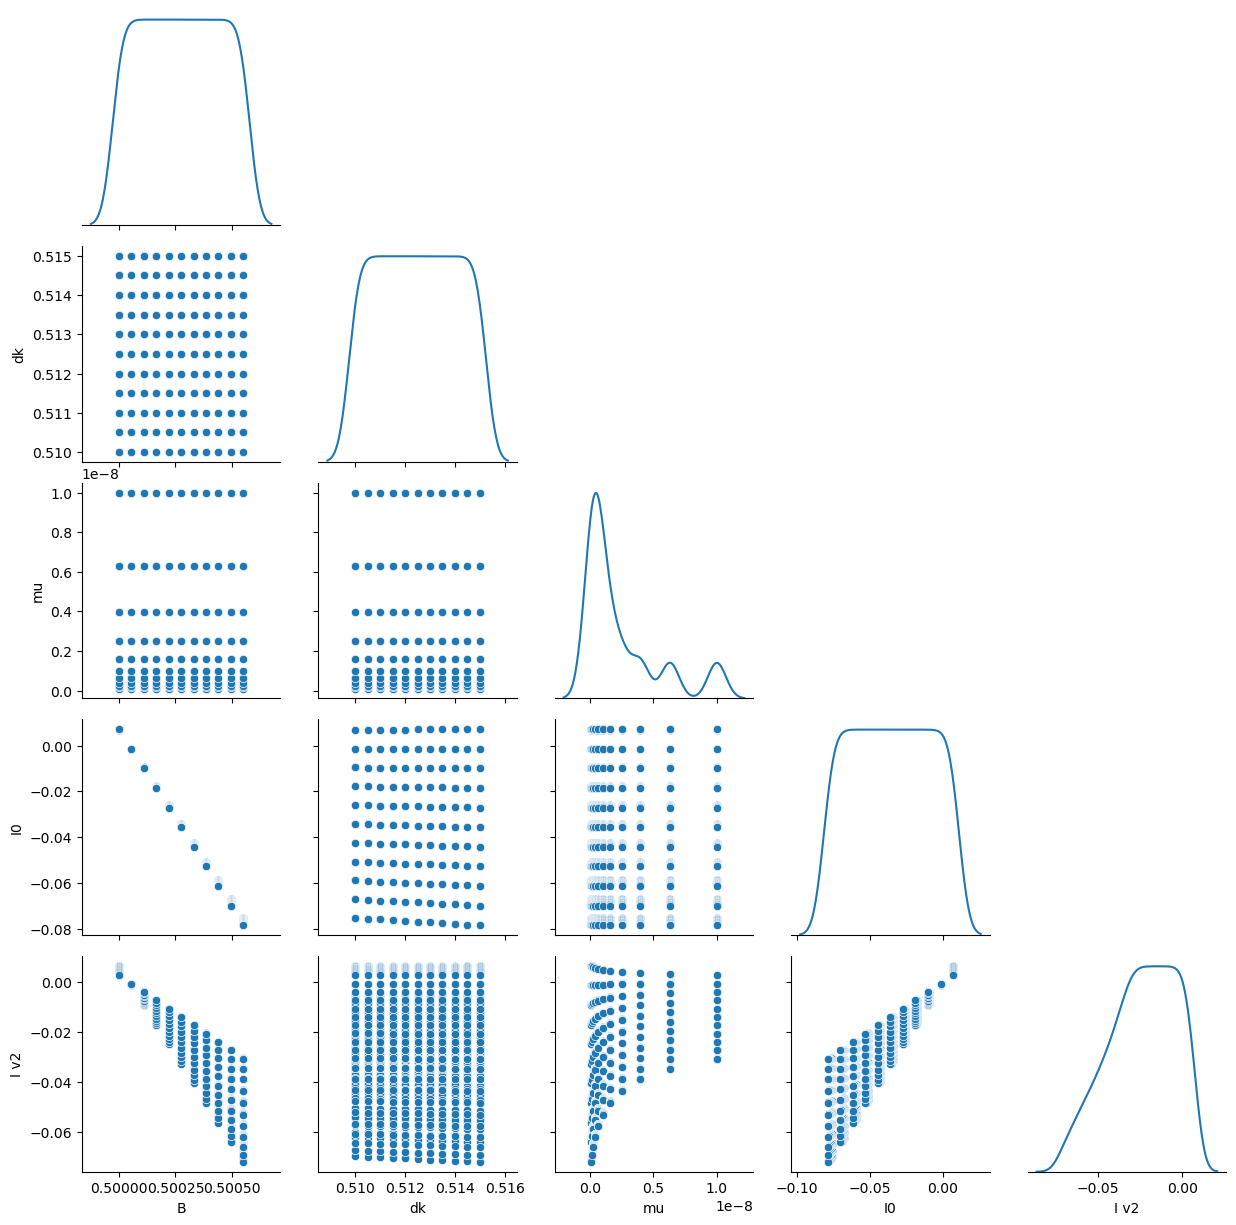

In [13]:
g = sns.PairGrid(tbl031[["B", "dk", "mu", "I0", "I v2"]], diag_sharey=False, corner=True)

g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)

From the plot above, it can be seen that increasing $\mu$ decreases the current, as all values of $I_j$ approach $I_j = 0$ as $\mu$ increases. I wish to model this with a power-law squeezing of the current based on $\mu$. We already know this is an emergent behavior, as our model for $I_j$ only contains $\mu$ as a parameter which determines $k_j$ and $M_j$. Technically, $\left| \psi(0) \right|^2$ also rescales $\mu$, but the dependence here is not linear or $\frac{1}{x}$, and $\left| \psi(0) \right|^2$ is held fixed for our model. The most likely source of this behavior is seen in the plots of the solutions of $\psi^\prime(0)$, where there tend to be matching values of $\psi^\prime(0)$ with $\left|\psi^\prime(0)\right|$ closer to the origin than the one solution for the linear case. This decreases the values of all quantities derived from $\psi^\prime(0)$, including $a_j$, $b_j$, $\left|\psi\right|_{max}$, and $I_j$.

In [14]:
# Redefine my table as a separate object, and not a slice
vals1 = tbl031[["B", "dk", "mu", "I0", "I v2"]].to_numpy()
# All the values are real, so there is no issue of casting the numbers as complex
tbl041 = pd.DataFrame(vals1, columns=["B", "dk", "\u03BC", "I0", "I\u03BC"])

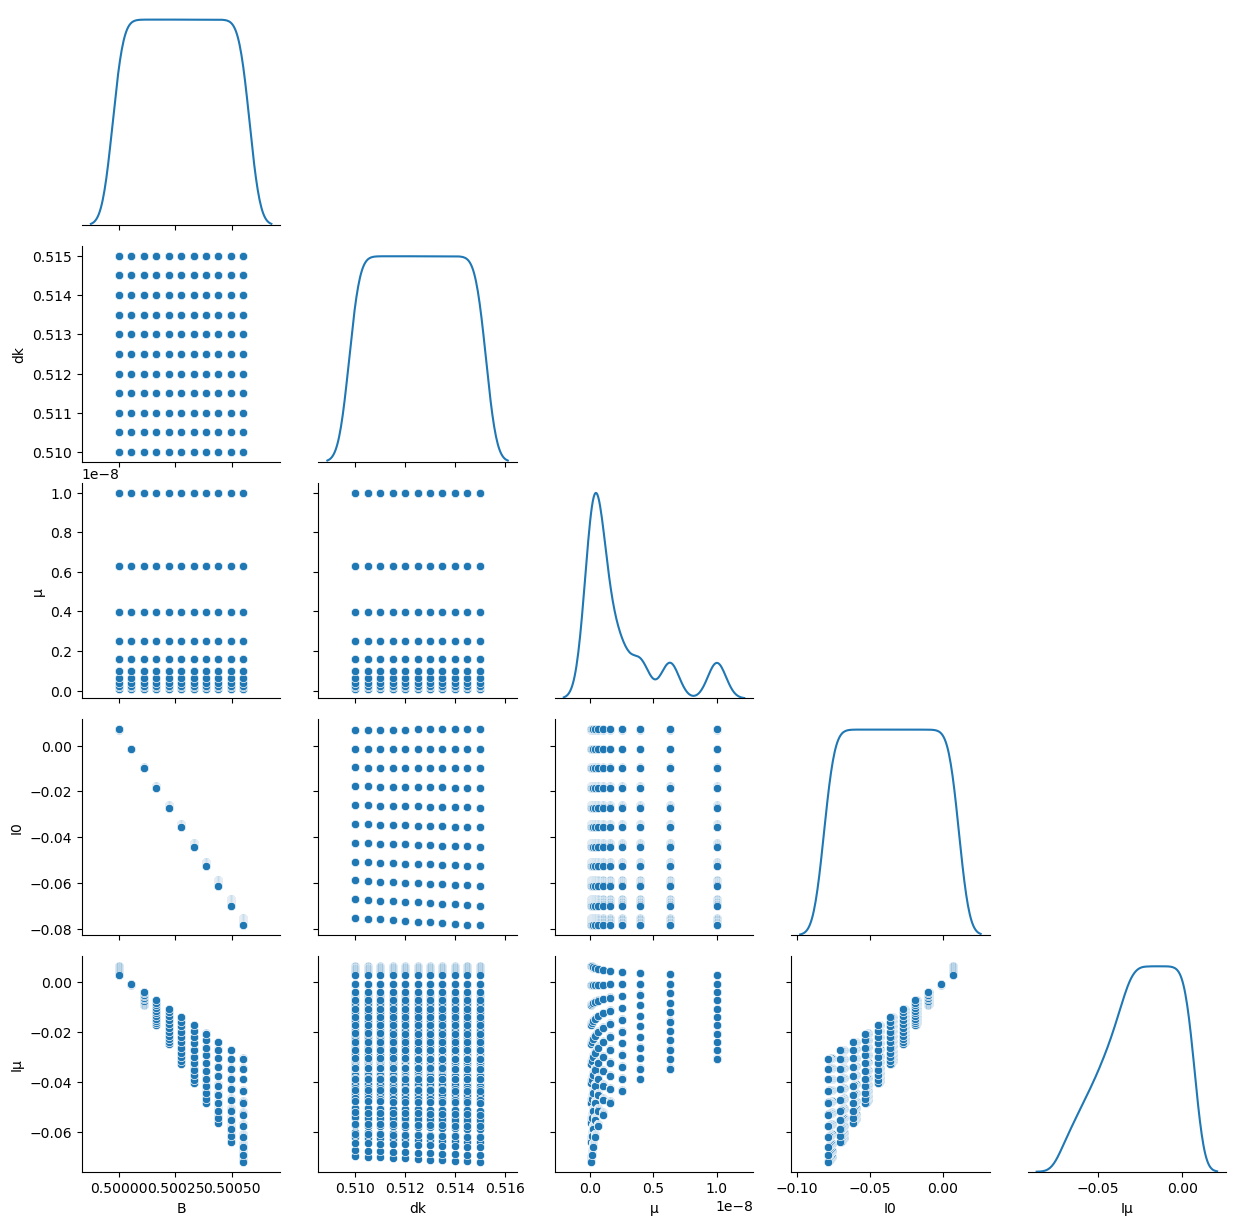

In [15]:
g = sns.PairGrid(tbl041, diag_sharey=False, corner=True)

g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)

Lets now fit the $\mu$ dependence to a power law.

In [16]:
# Linear Regression

ng = B3_arr.shape[0] # Get the size of my grid from my arrays.
slope = np.zeros((ng, ng))
intercept = np.zeros((ng, ng))
r = 1.1    # For finding the minimum r value.

for i in range(ng):
    for j in range(ng):
        tbl_n = tbl041[(tbl041["B"]==B3_arr[i])&(tbl041["dk"]==dk3_arr[j])]
        X = np.log(tbl_n["\u03BC"].to_numpy()) # Power laws are straight lines on log-log plots.
        X=X.reshape(-1, 1)
        y = np.log(np.abs(tbl_n["I\u03BC"].to_numpy())) # Power laws are straight lines on log-log plots.
                                                        # Taking the logrithm requires a positive number.

        reg = LinearRegression().fit(X, y)

        slope[i,j]=reg.coef_[0]
        intercept[i,j]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

# Convergence statistic of worst convergence.
print(r) 

0.9720862723334327


In [17]:
print(f"Average fitted power of \u03BC: {np.average(slope)}\nStandard Deviation:   {np.std(slope)}")

Average fitted power of μ: -0.1840921118960578
Standard Deviation:   0.0032747355548618847


In [18]:
print(f"Average ln of coefficient of \u03BC: {np.average(intercept)}\nStandard Deviation:   {np.std(intercept)}")

Average ln of coefficient of μ: -7.99974617385278
Standard Deviation:   1.1278719046609018


Our power is a reasonable fit to our curve, but different values of $B$ and $k$ have different coefficients. 

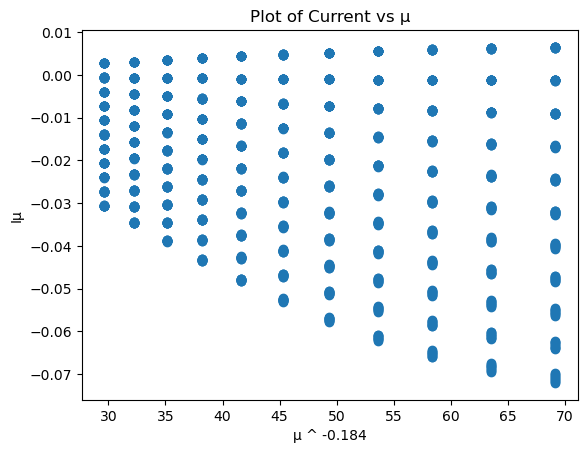

In [19]:
# Define our plot object

fig, ax = plt.subplots()
plt.title(f"Plot of Current vs \u03BC")
ax.set_ylabel('I\u03BC')
ax.set_xlabel("\u03BC ^ -0.184")

x = np.power(tbl041["\u03BC"], -0.184) # I take mu to the power found from our fit.
y = tbl041["I\u03BC"]

ax.scatter(x, y)

plt.show()

The $\mu$ dependence of $I_j$ is not quite linear here, but it is somewhat linear. For an emergent characteristic, it is not bad.

I am now going to fit the $\mu$ dependence of $I_{ee}/I_0$. 

In [20]:
ng = B3_arr.shape[0] # Get the size of my grid from my arrays.
slope = np.zeros((ng, ng))
intercept = np.zeros((ng, ng))
r = 1.1    # for finding the minimum r value

for i in range(ng):
    for j in range(ng):
        tbl_n = tbl041[(tbl041["B"]==B3_arr[i])&(tbl041["dk"]==dk3_arr[j])]
        X = np.log(tbl_n["\u03BC"].to_numpy())
        X=X.reshape(-1, 1)
        y = np.log(np.abs(tbl_n["I\u03BC"].to_numpy()/tbl_n["I0"].to_numpy())) # Ratio of currents

        reg = LinearRegression().fit(X, y)

        slope[i,j]=reg.coef_[0]
        intercept[i,j]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

print(r)

0.9720862723334327


In [21]:
print(f"Average fitted power of \u03BC: {np.average(slope)}\nStandard Deviation:   {np.std(slope)}")

Average fitted power of μ: -0.1840921118960578
Standard Deviation:   0.0032747355548618843


In [22]:
print(f"Average ln of coefficient of \u03BC: {np.average(intercept)}\nStandard Deviation:   {np.std(intercept)}")

Average ln of coefficient of μ: -4.2428683094960125
Standard Deviation:   0.07527349296612179


The slope is unchanged, but the variation of the intercept is decreased significantly. 

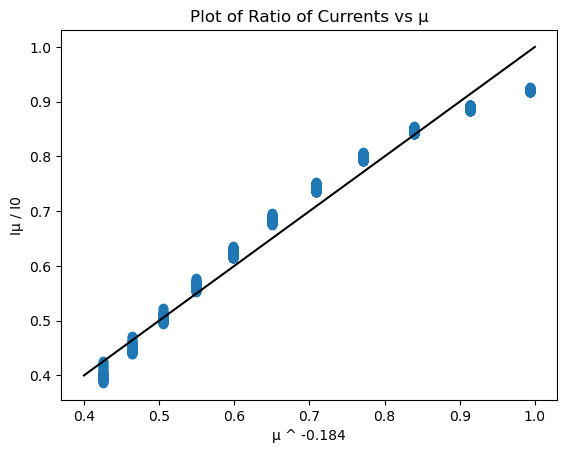

In [23]:
# Define our plot object
fig, ax = plt.subplots()
plt.title(f"Plot of Ratio of Currents vs \u03BC")
ax.set_ylabel('I\u03BC / I0')
ax.set_xlabel("\u03BC ^ -0.184")

x = np.power(tbl041["\u03BC"], -0.184)*np.exp(-4.2428683094960125)
y = tbl041["I\u03BC"]/tbl041["I0"]
x2 = np.linspace(0.4, 1.0, 100)

ax.plot(x2,x2, color="black")
ax.scatter(x, y)

plt.show()

The data is not linear here, but somewhat close. I see the possibility of constructing a better by adding another term, but I don't see a reason to find such a model, as this is not supposed to be a usable result, but rather a conceptual result. 
Our model is:
\begin{equation}
\frac{I_\mu}{I_0} = 0.0144 \, \mu^{-0.184} 
\end{equation}
However, this fit was found from a small subset of our data, so is not very useful.

# Grid with R dependence

I want to try to do the same thing with a dataset which occupies all of my expected parameter range.

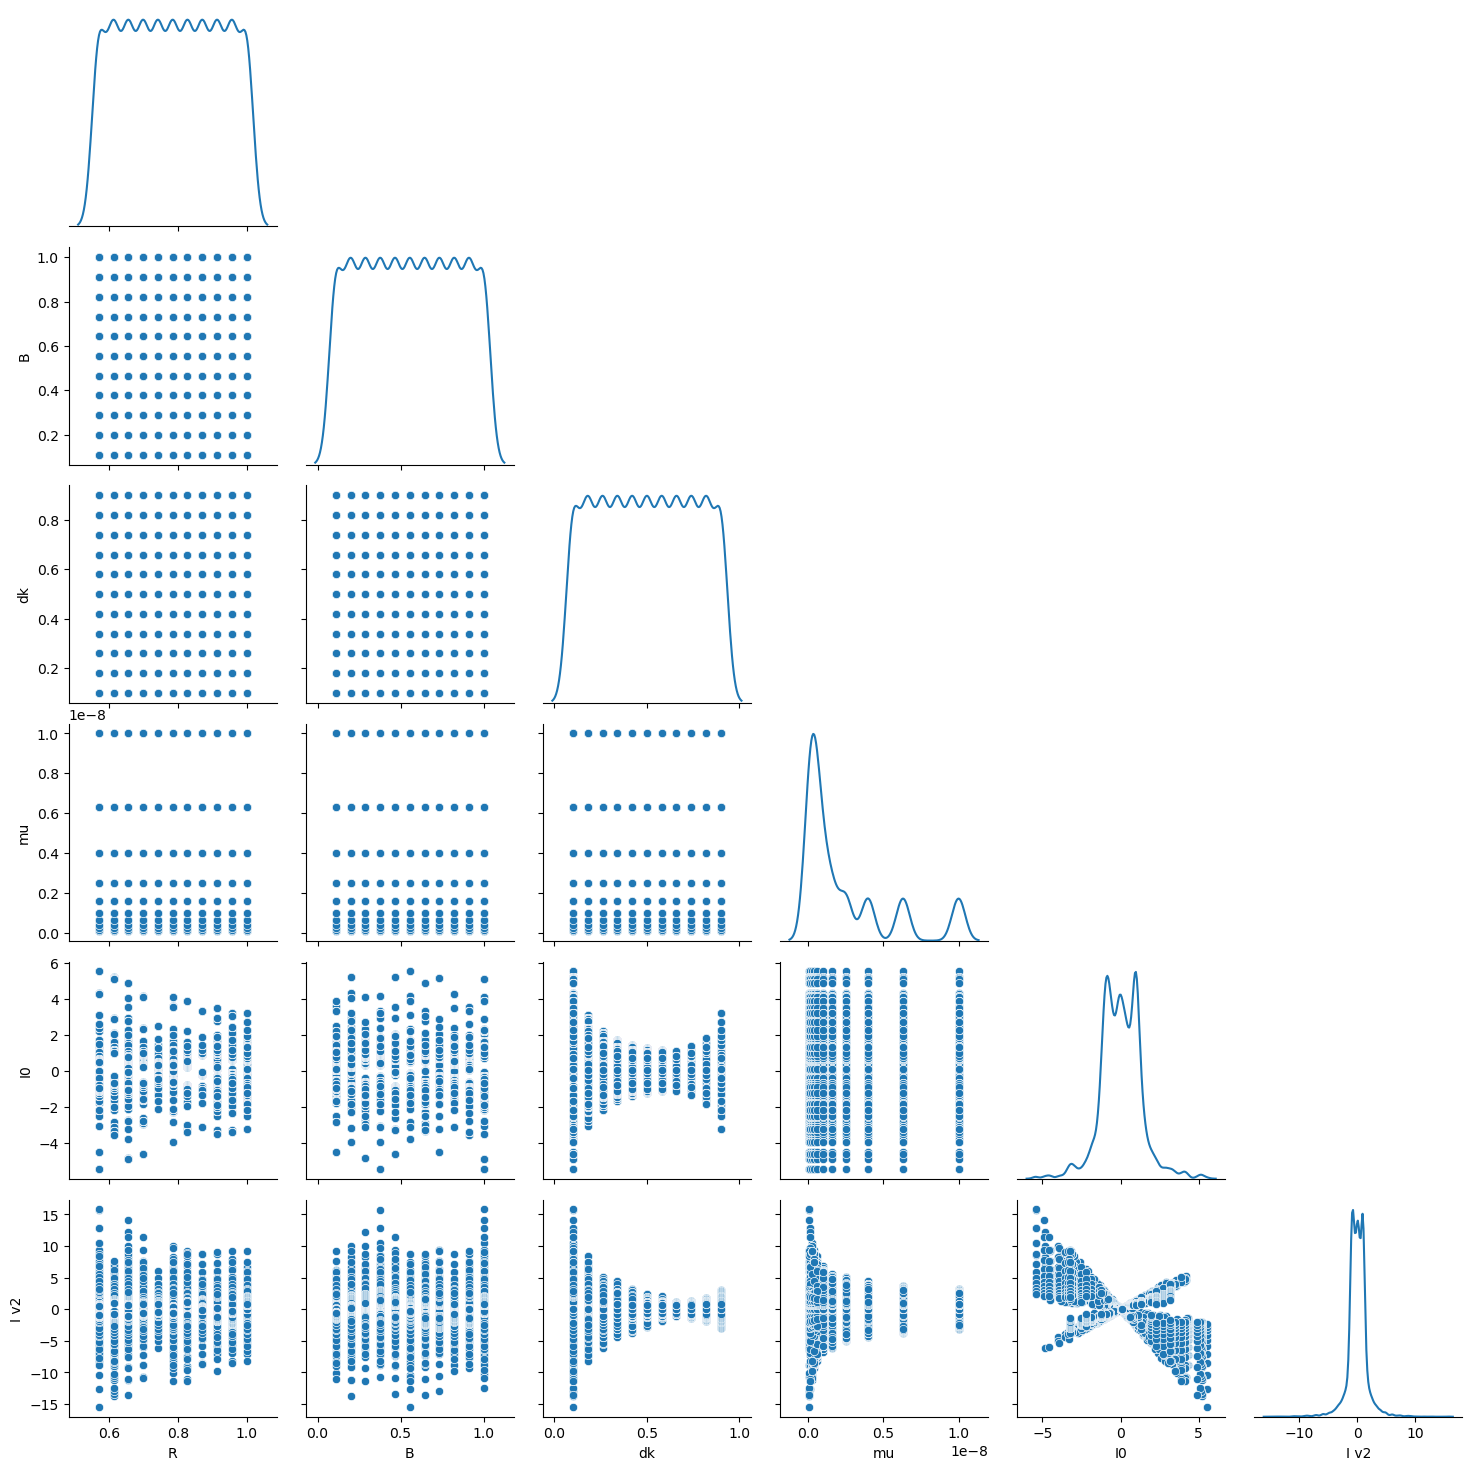

In [24]:
g = sns.PairGrid(tbl023[["R", "B", "dk", "mu", "I0", "I v2"]], diag_sharey=False, corner=True)

g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)

From the plot above, the decreasing current with increasing $\mu$ remains. A $dk$ shape also appears, but we already know that it is from the oscillation structure, not large-scale structure.

In [12]:
# Redefine my table as a separate object, and not a slice
vals1 = tbl023[["R", "B", "dk", "mu", "I0", "I v2"]].to_numpy()
# All the values are real, so there is no issue of casting the numbers as complex
tbl043 = pd.DataFrame(vals1, columns=["R", "B", "dk", "\u03BC", "I0", "I\u03BC"])

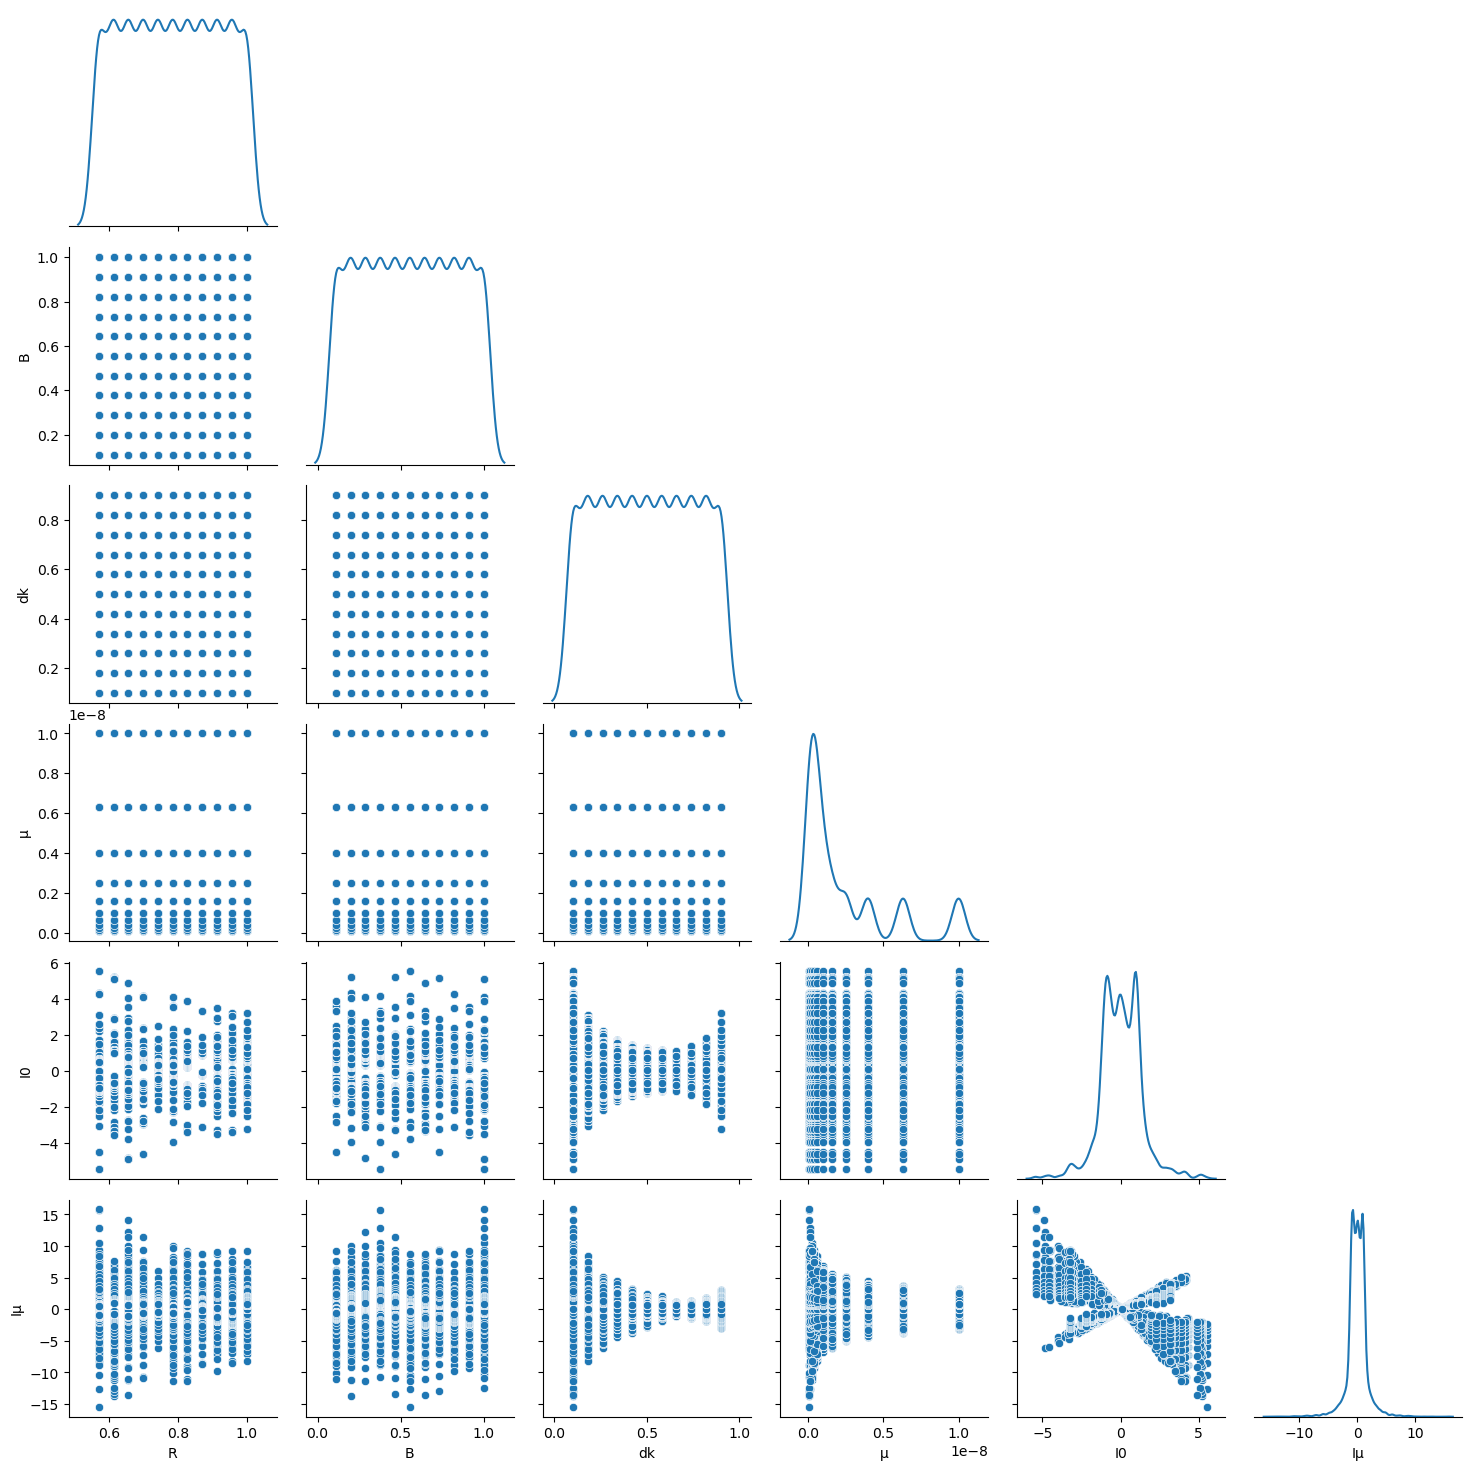

In [26]:
g = sns.PairGrid(tbl043, diag_sharey=False, corner=True)

g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)

In [13]:
gs = R2_arr.shape[0] # Size of our grid
# When I labeled these shapes, the second R, B, etc. arrays came from the third table, which was the fourth dataset. 
# This naming convention comes from my BVP to end notebook.
# While I could fix the naming convention now, it seems unnecessary. I have fixed this for the BVP_k_M notebook.

In order to properly extract the pattern, we need to find the minimum and maximum current $I_{\mu}$ for a given $\mu$ value. 

This analysis is done on a grid so that I can select $\mu$ values and find the minimum and maximum current of each value of $\mu$. To do this with the proper Monte Carlo analysis, I would need to choose random $\mu$ values, then random values of the other parameters for a number of points for each such value of $\mu$. I could set this up, but so far have not added this variant.

In [14]:
I_min = np.zeros(gs)
I_max = np.zeros(gs)
for i, mun in enumerate(mu2_arr):
    tbl_n = tbl043[(tbl043["\u03BC"]==mun)]
    I_min[i] = np.min(tbl_n["I\u03BC"].to_numpy())
    I_max[i] = np.max(tbl_n["I\u03BC"].to_numpy())

In [22]:
np.min(tbl043["I0"]), np.max(tbl043["I0"])

(-5.4343528321083685, 5.510228517947295)

And now to plot our maxima and minima.

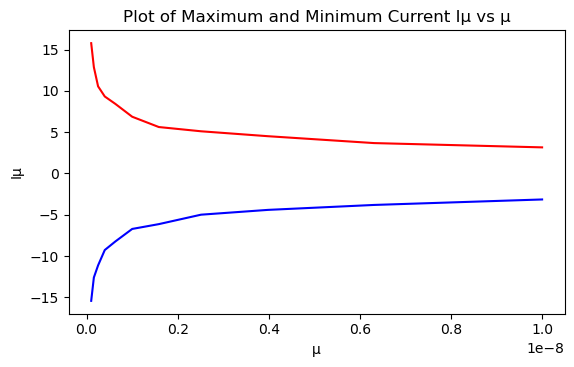

In [15]:
fig, ax = plt.subplots()
plt.title(f"Plot of Maximum and Minimum Current I\u03BC vs \u03BC")
ax.set_ylabel('I\u03BC')
ax.set_xlabel("\u03BC")

x = mu2_arr
y1 = I_min
y2 = I_max

ax.plot(x, y1, color = "blue")
ax.plot(x, y2, color = "red")

ax.set_box_aspect(2.0/3.5)


plt.show()


The next plot is our log-log plot: $\ln\left|I_{max}\right|$ and $\ln\left|I_{min}\right|$ vs $\ln\left(\mu\right)$. If this dependence follows a power-law, the graphs will be straight lines.

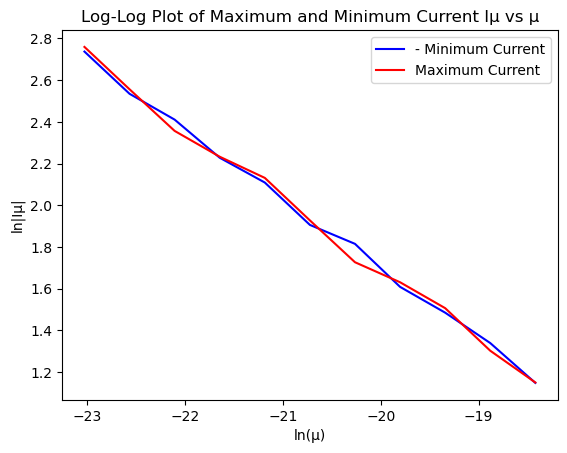

In [16]:
fig, ax = plt.subplots()
plt.title(f"Log-Log Plot of Maximum and Minimum Current I\u03BC vs \u03BC")
ax.set_ylabel('ln|I\u03BC|')
ax.set_xlabel("ln(\u03BC)")

x = mu2_arr
y1 = I_min
y2 = I_max

# Plot logrithm to visually inspect power-law dependence
ax.plot(np.log(x), np.log(np.abs(y1)), color = "blue", label = "- Minimum Current")
ax.plot(np.log(x), np.log(y2), color = 'red', label = "Maximum Current")

plt.legend()

plt.show()

They indeed look straight, and fall on top of each other, as would be expected if there is no preferred sign of $I$. Lets now fit the $\mu$ dependence to a power law. I will apply linear regression to $\ln\left(I_{max}\right)$ first, then $\ln\left(-I_{min}\right)$. I will use the average values for the power of $\mu$ and its coefficient as my model.

In [17]:
# Linear regression

X = np.log(mu2_arr) # Power laws are straight lines on log-log plots.
X=X.reshape(-1, 1)
y = np.log(np.abs(I_max)) # Power laws are straight lines on log-log plots.

reg = LinearRegression().fit(X, y)

slope_max=reg.coef_[0]
intercept_max=reg.intercept_

r = reg.score(X, y)

print("For the linear regression of ln(I_max) vs ln(\u03BC)")
print(f"Fitted power of \u03BC:      {slope_max}")
print(f"ln of coefficient of \u03BC: {intercept_max}")
print("Convergence Statistic:  ", r) 

For the linear regression of ln(I_max) vs ln(μ)
Fitted power of μ:      -0.33979964670706825
ln of coefficient of μ: -5.107234006282443
Convergence Statistic:   0.9961475604956803


In [18]:
# Regression

r = 1.1    # for finding the minimum r value

X = np.log(mu2_arr) # Power laws are straight lines on log-log plots.
X=X.reshape(-1, 1)
y = np.log(np.abs(I_min)) # Power laws are straight lines on log-log plots.

reg = LinearRegression().fit(X, y)

slope_min=reg.coef_[0]
intercept_min=reg.intercept_

r = reg.score(X, y)

print("For the linear regression of ln(-I_min) vs ln(\u03BC)")
print(f"Fitted power of \u03BC:      {slope_min}")
print(f"ln of coefficient of \u03BC: {intercept_min}")
print("Convergence Statistic:  ", r) 

For the linear regression of ln(-I_min) vs ln(μ)
Fitted power of μ:      -0.33618460119868776
ln of coefficient of μ: -5.028664950893603
Convergence Statistic:   0.9980758639161558


In [19]:
slope = np.average([slope_max, slope_min])
intercept = np.average([intercept_max, intercept_min])
print("Average Slope:     ", slope)
print("Average Intercept: ", intercept)
print("Coefficent of \u03BC: ", np.exp(intercept))

Average Slope:      -0.33799212395287803
Average Intercept:  -5.067949478588023
Coefficent of μ:  0.0062953155945024404


Now I will add this model to both the log-log and the linear-linear plots. 

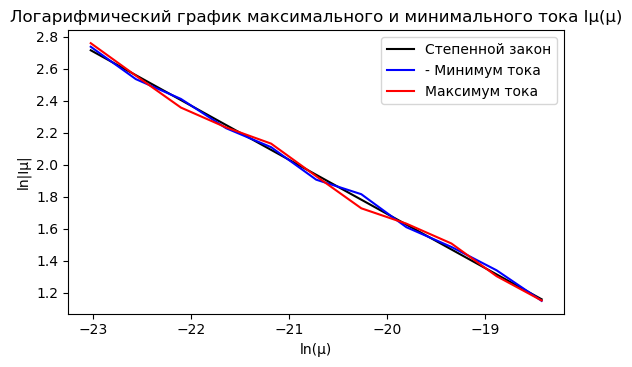

In [20]:
# Define our plot object
fig, ax = plt.subplots()
plt.title(f"Логарифмический график максимального и минимального тока I\u03BC(\u03BC)")
ax.set_ylabel('ln|I\u03BC|')
ax.set_xlabel("ln(\u03BC)")

x = mu2_arr
y1 = I_min
y2 = I_max

# Plot logrithm to visually inspect power-law dependence
ax.plot(np.log(x), slope* np.log(x) + intercept, color = "black", label = "Степенной закон")
ax.plot(np.log(x), np.log(np.abs(y1)), color = "blue", label = "- Минимум тока")
ax.plot(np.log(x), np.log(y2), color = "red", label = "Максимум тока")

plt.legend()

ax.set_box_aspect(2.0/3.5)

plt.savefig("loglog_mu_I.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

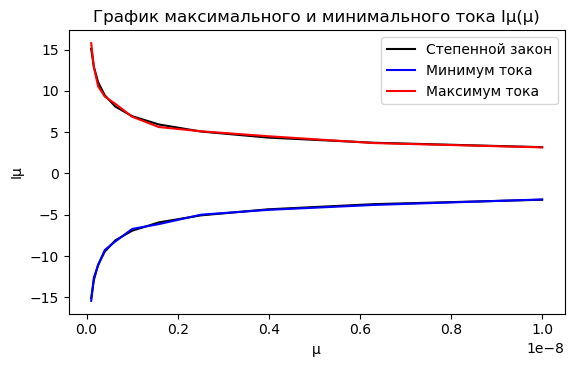

In [21]:
# Define our plot object
fig, ax = plt.subplots()
plt.title(f"График максимального и минимального тока I\u03BC(\u03BC)")
ax.set_ylabel('I\u03BC')
ax.set_xlabel("\u03BC")

x = mu2_arr
y1 = I_min
y2 = I_max

ax.plot(x, np.exp(slope* np.log(x) + intercept), color = "black", label = "Степенной закон")
ax.plot(x, -np.exp(slope* np.log(x) + intercept), color = "black")
ax.plot(x, y1, color = "blue", label = "Минимум тока")
ax.plot(x, y2, color = "red", label = "Максимум тока")

plt.legend()
ax.set_box_aspect(2.0/3.5)

plt.savefig("lin_mu_I.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

This model works well. The numbers which I found are as follows:
\begin{equation}
\left|I_\mu\right|_{max} = 0.006295 \, \mu^{-0.338} 
\end{equation}

There is a slight complication, as this doesn't predict what will happen as $\mu$ approaches $0$, since the model goes to infinity as $\mu$ approaches $0$. However, $I_0$ actually has a smaller range than $I_\mu$ for this dataset. So the model breaks down for some small value of $\mu$. This is to be expected, as it is not unusual for emergent behavior.